Calculando F1-Score...


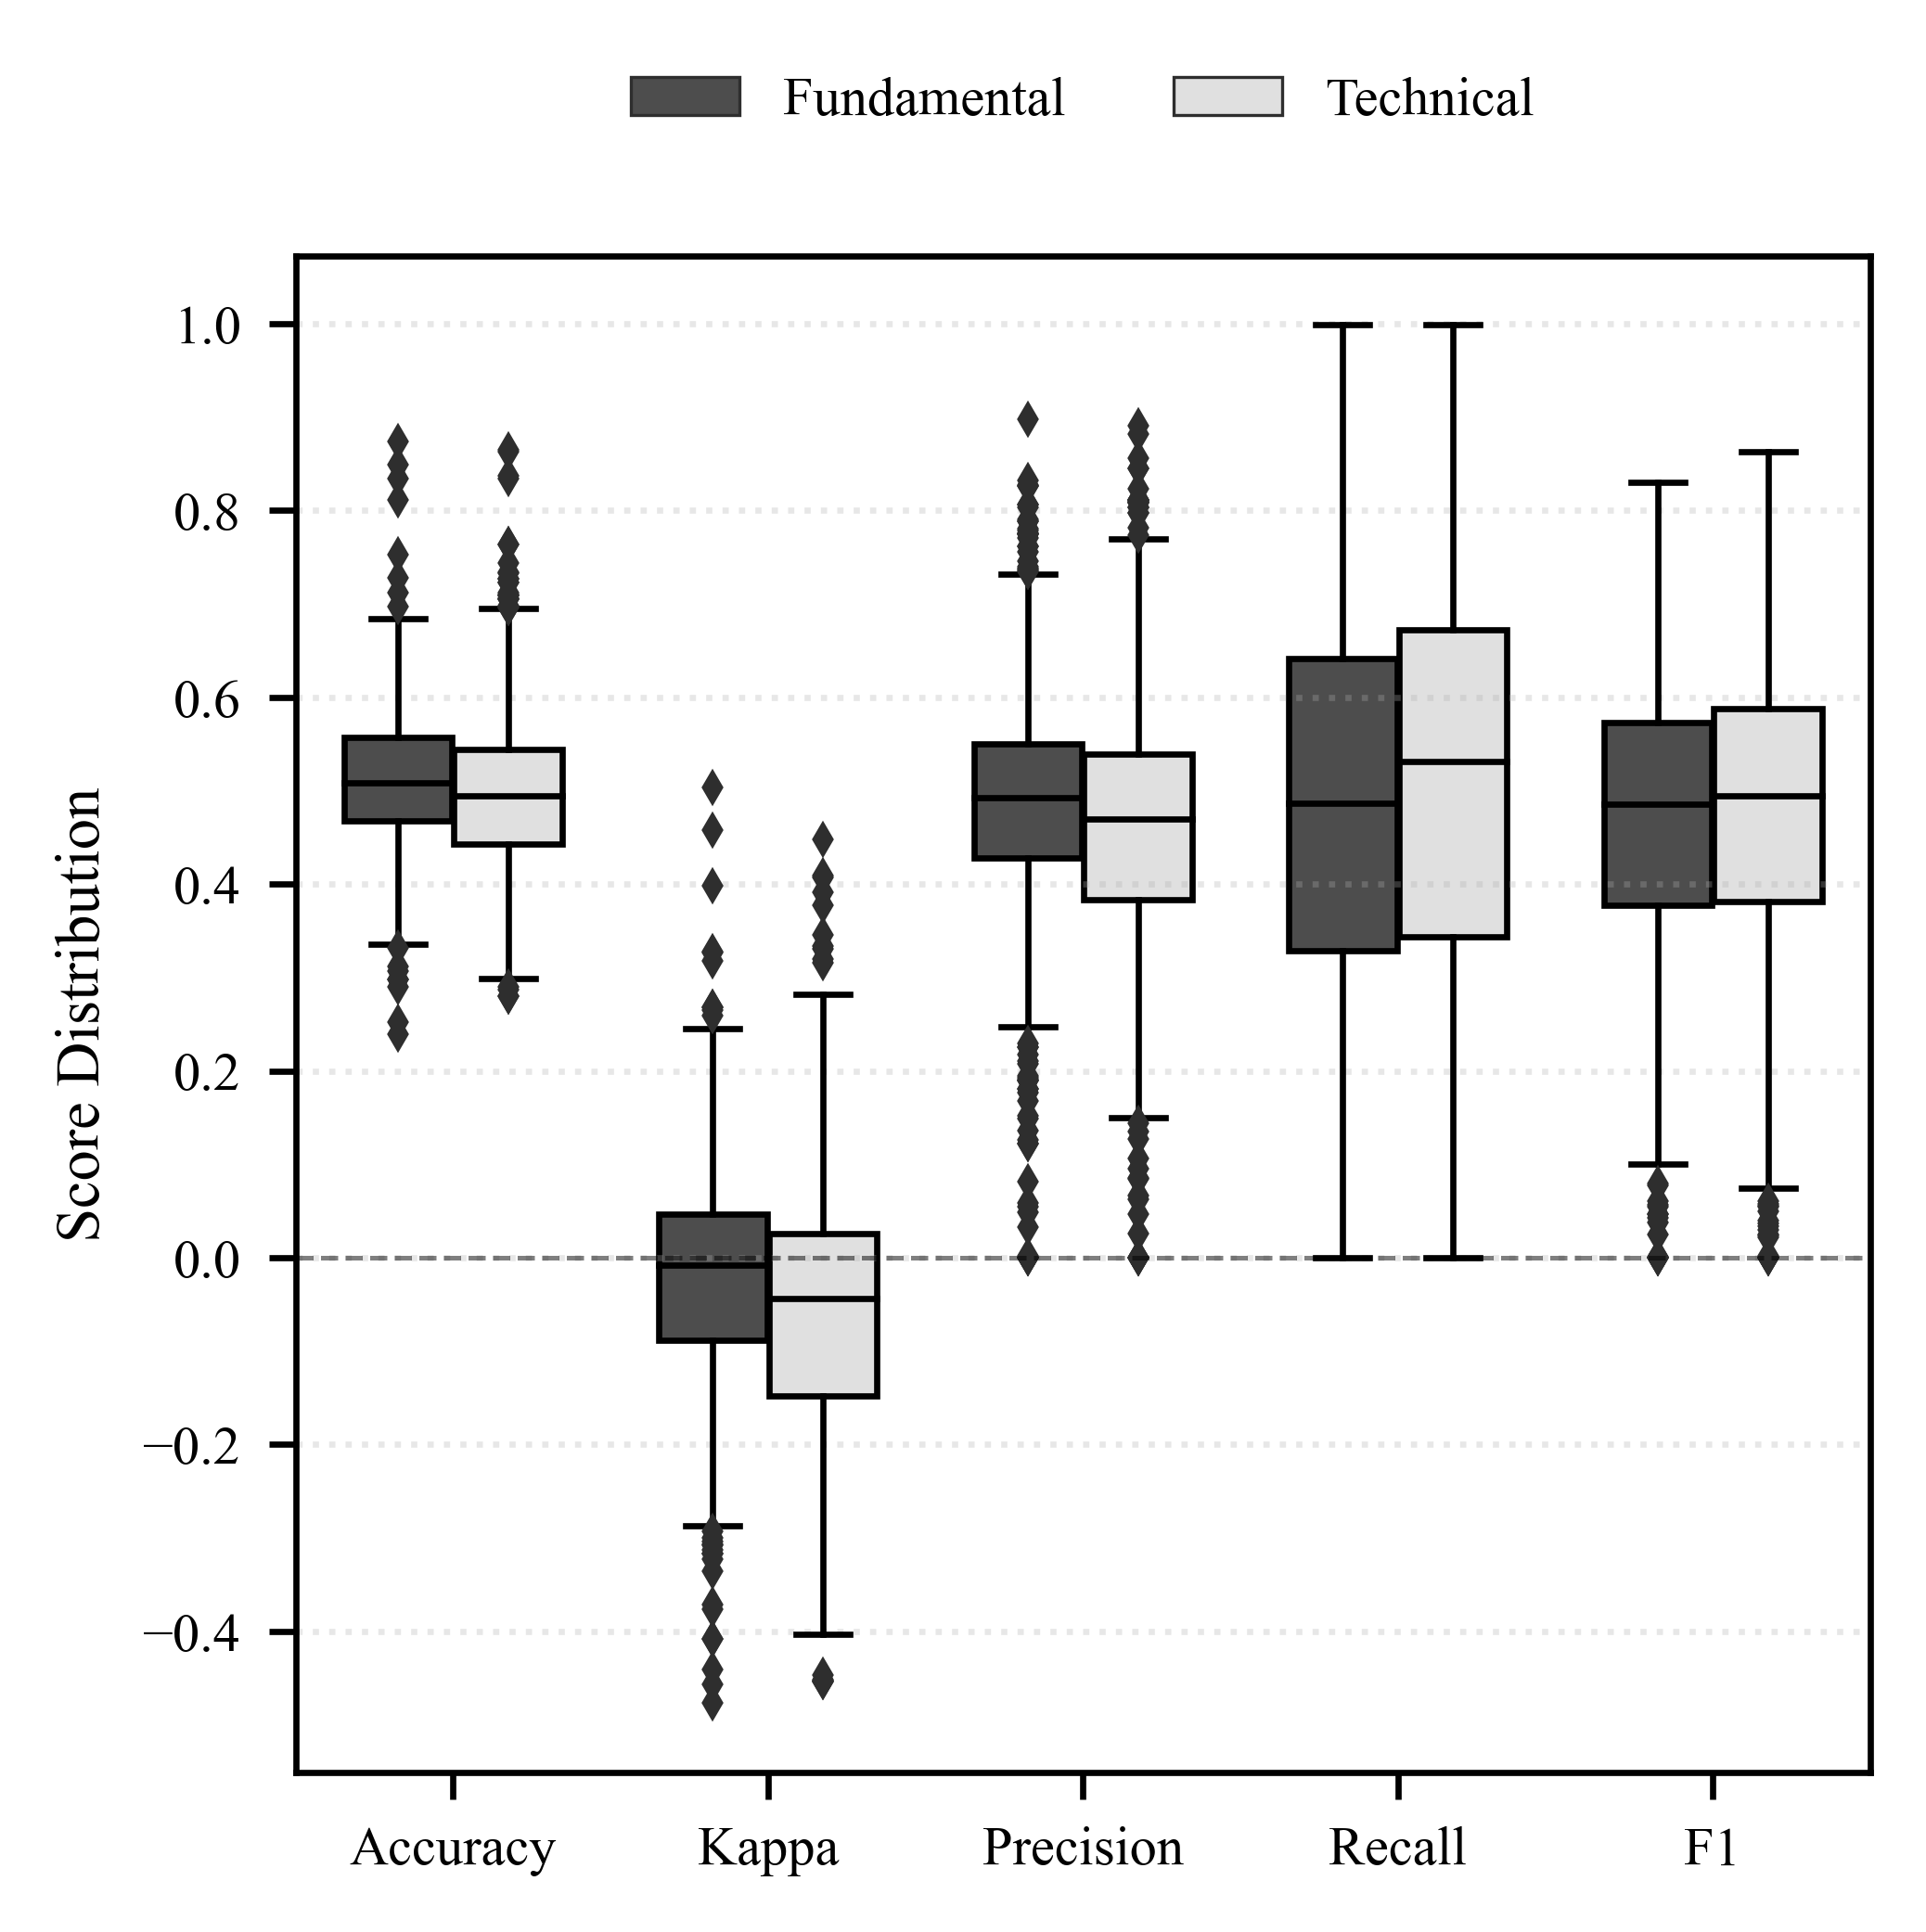

Gráfico Boxplot salvo em: figuras/metrics_distribution_lag1.pdf


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.font_manager as fm

# ==============================================================================
# 1. CARREGAMENTO FORÇADO DA FONTE (TIMES NEW ROMAN)
# ==============================================================================
caminhos_possiveis = [
    os.path.expanduser('~/.local/share/fonts/times.ttf'),
    os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf'),
    '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf',
    'C:/Windows/Fonts/times.ttf'
]

caminho_fonte = None
for p in caminhos_possiveis:
    if os.path.exists(p):
        caminho_fonte = p
        break

try:
    if caminho_fonte:
        fm.fontManager.addfont(caminho_fonte)
        prop = fm.FontProperties(fname=caminho_fonte)
        nome_exato_fonte = prop.get_name()
    else:
        nome_exato_fonte = 'serif'
except:
    nome_exato_fonte = 'serif'

# ==============================================================================
# 2. CONFIGURAÇÕES IEEE (SINGLE COLUMN)
# ==============================================================================
modelo = 'HT'
atraso_selecionado = 1 
caminho_base = 'resultados'
nome_arquivo_saida = f'figuras/metrics_distribution_lag{atraso_selecionado}.pdf'

plt.rcParams.update({
    'font.family': nome_exato_fonte,
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,
    'lines.linewidth': 0.8,
    'lines.markersize': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}

# --- CORREÇÃO DE CORES ---
# Fundamental = Cinza Escuro (#4D4D4D)
# Technical = Cinza Claro (#E0E0E0) - Garante contraste visual
palette_pb = {'Fundamental': '#4D4D4D', 'Technical': '#E0E0E0'} 

# ==============================================================================
# 3. CARREGAMENTO E LIMPEZA
# ==============================================================================
nome_arquivo = f'resultados_{modelo}_atraso_{atraso_selecionado}.csv'
caminho_completo = os.path.join(caminho_base, nome_arquivo)

try:
    if os.path.exists(caminho_completo):
        df = pd.read_csv(caminho_completo)
    else:
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_completo}")

    # Limpeza numérica
    cols_numericas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
    for col in cols_numericas:
        if col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(',', '.')
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Cálculo F1 (Se não existir ou estiver vazio)
    if 'F1' not in df.columns or df['F1'].isnull().all():
        if 'Precision' in df.columns and 'Recall' in df.columns:
            print("Calculando F1-Score...")
            df['F1'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall'] + 1e-9)

    # Prepara DF Longo
    metricas_disponiveis = [m for m in cols_numericas if m in df.columns]
    
    # --- CORREÇÃO: ADICIONADO 'F1' NA ORDEM DE PLOTAGEM ---
    ordem_metricas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
    metricas_finais = [m for m in ordem_metricas if m in metricas_disponiveis]
    
    df['Domain'] = df['categoria'].map(mapa_nomes)
    df_plot = df[df['Domain'].notna()].copy()

    df_melted = df_plot.melt(
        id_vars=['Domain'], 
        value_vars=metricas_finais,
        var_name='Metric', 
        value_name='Score'
    )

    # ==============================================================================
    # 4. PLOTAGEM CORRIGIDA
    # ==============================================================================
    plt.figure(figsize=(3.5, 3.5))

    ax = sns.boxplot(
        data=df_melted,
        x='Metric', y='Score', hue='Domain',
        palette=palette_pb,
        linewidth=0.8,
        fliersize=2,
        width=0.7,
        saturation=1  # Mantém a cor sólida da paleta
    )

    # --- CORREÇÃO DO VISUAL DAS CAIXAS ---
    # Itera sobre cada caixa desenhada para garantir borda preta, 
    # MAS mantém a cor de preenchimento original (facecolor)
    for i, artist in enumerate(ax.artists):
        # A borda fica preta para contraste
        artist.set_edgecolor('black')
        # A linha interna (whisker/caps) é controlada por ax.lines, não aqui
        
    # Garante que medianas e whiskers sejam pretos
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(0.8)

    plt.xlabel('') 
    plt.ylabel('Score Distribution')
    
    # Linha zero discreta
    plt.axhline(0, color='black', linestyle='--', linewidth=0.6, alpha=0.5)
    
    # Legenda Ajustada
    plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, 1.15), 
               ncol=2, frameon=False, fontsize=7)

    plt.tight_layout()
    
    plt.savefig(nome_arquivo_saida, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()
    print(f"Gráfico Boxplot salvo em: {nome_arquivo_saida}")

except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"ERRO: {e}")

Agrupando por ativo (média dos horizontes)...


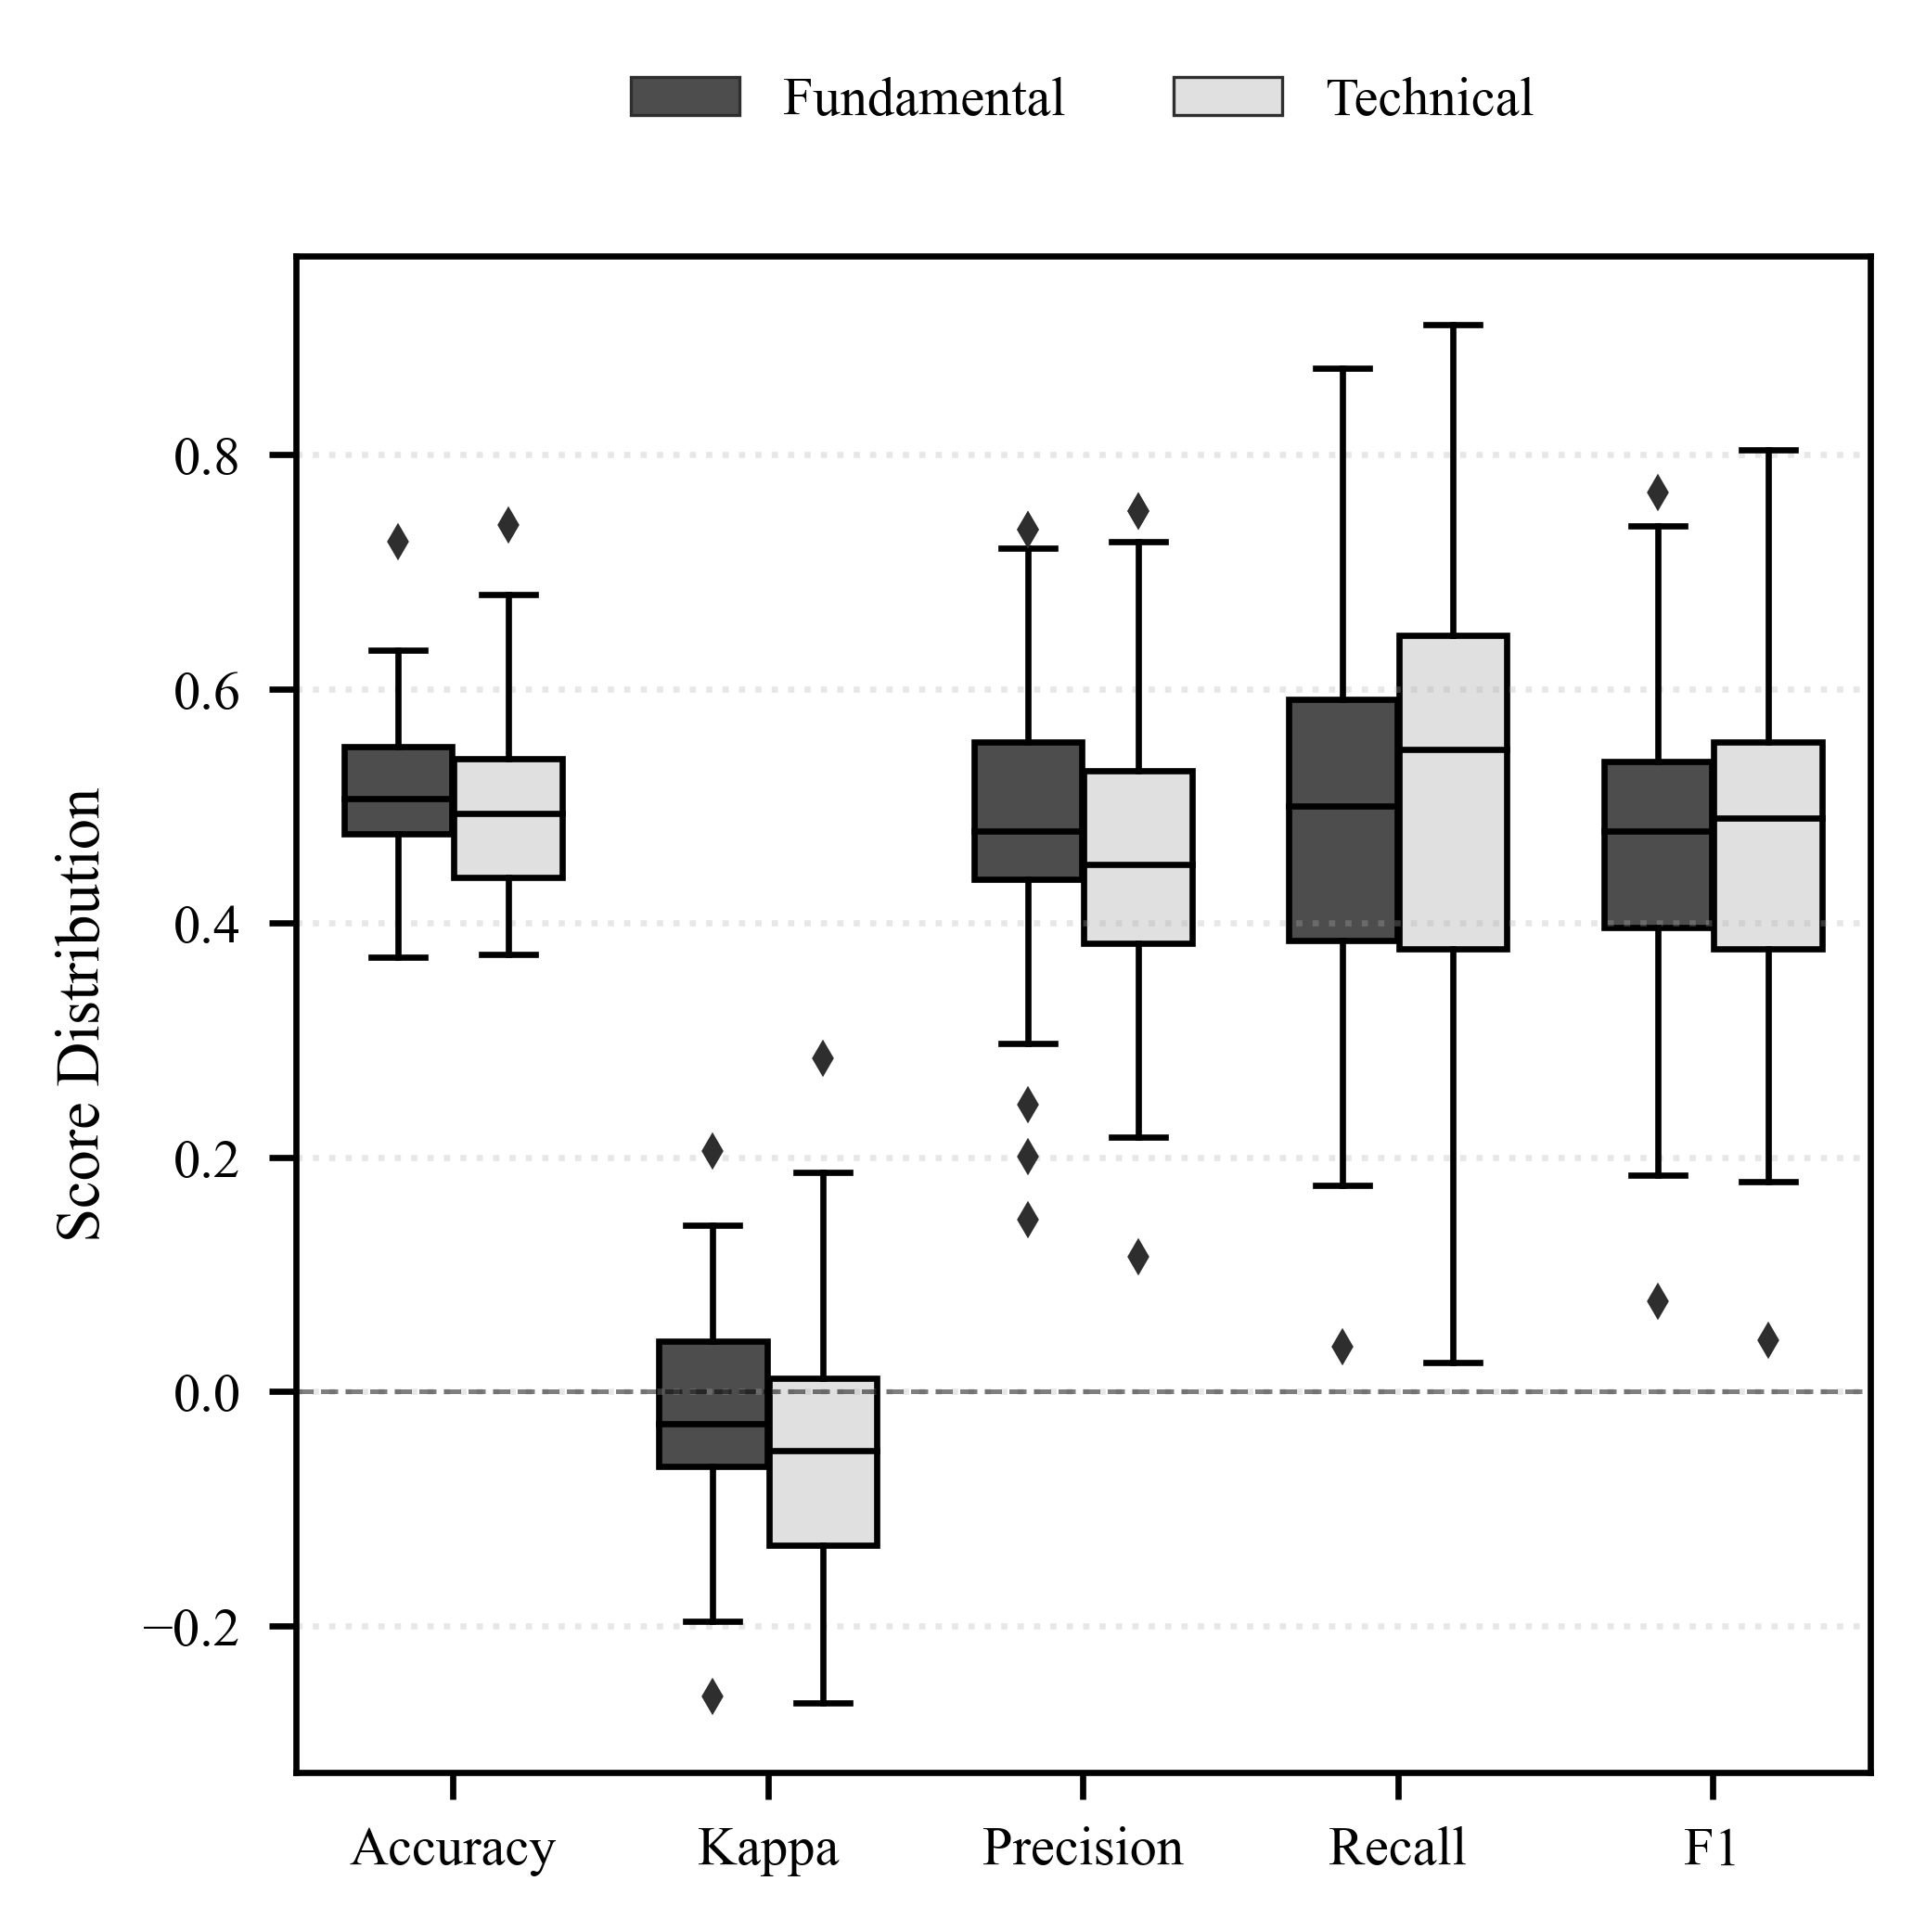

Gráfico salvo: figuras/metrics_distribution_lag1.pdf

DETALHAMENTO ESTATÍSTICO DOS BOXPLOTS (58 ATIVOS)
                       Base da Caixa (Q1)  Mediana  Topo da Caixa (Q3)
Metric    Domain                                                      
Accuracy  Fundamental              0.4765   0.5061              0.5505
          Technical                0.4386   0.4938              0.5401
Kappa     Fundamental             -0.0642  -0.0274              0.0430
          Technical               -0.1311  -0.0507              0.0110
Precision Fundamental              0.4370   0.4786              0.5544
          Technical                0.3828   0.4499              0.5301
Recall    Fundamental              0.3851   0.5001              0.5913
          Technical                0.3782   0.5481              0.6454
F1        Fundamental              0.3964   0.4787              0.5379
          Technical                0.3780   0.4896              0.5543

INTERPRETAÇÃO RÁPIDA:
- Se a Mediana do Fun

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.font_manager as fm

# ==============================================================================
# 1. CARREGAMENTO FORÇADO DA FONTE
# ==============================================================================
caminhos_possiveis = [
    os.path.expanduser('~/.local/share/fonts/times.ttf'),
    os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf'),
    '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf',
    'C:/Windows/Fonts/times.ttf'
]

caminho_fonte = None
for p in caminhos_possiveis:
    if os.path.exists(p):
        caminho_fonte = p
        break

try:
    if caminho_fonte:
        fm.fontManager.addfont(caminho_fonte)
        prop = fm.FontProperties(fname=caminho_fonte)
        nome_exato_fonte = prop.get_name()
    else:
        nome_exato_fonte = 'serif'
except:
    nome_exato_fonte = 'serif'

# ==============================================================================
# 2. CONFIGURAÇÕES IEEE
# ==============================================================================
modelo = 'HT'
atraso_selecionado = 1 
caminho_base = 'resultados'
nome_arquivo_saida = f'figuras/metrics_distribution_lag{atraso_selecionado}.pdf'

plt.rcParams.update({
    'font.family': nome_exato_fonte,
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 600,
    'lines.linewidth': 0.8,
    'lines.markersize': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
palette_pb = {'Fundamental': '#4D4D4D', 'Technical': '#E0E0E0'} 

# ==============================================================================
# 3. CARREGAMENTO E PROCESSAMENTO
# ==============================================================================
nome_arquivo = f'resultados_{modelo}_atraso_{atraso_selecionado}.csv'
caminho_completo = os.path.join(caminho_base, nome_arquivo)

try:
    if os.path.exists(caminho_completo):
        df = pd.read_csv(caminho_completo)
    else:
        # MOCK DE DADOS (CASO NÃO TENHA O ARQUIVO AGORA)
        print("AVISO: Usando dados mockados.")
        data = []
        bases = [f'Ativo_{i}' for i in range(58)]
        horizontes = [1, 30, 60, 90, 120, 150, 180, 210, 240]
        for b in bases:
            for h in horizontes:
                for cat in ['fund', 'nao_fund']:
                    data.append({
                        'base': b, 'fh': h, 'categoria': cat,
                        'Accuracy': 0.52 + np.random.normal(0, 0.05),
                        'Kappa': 0.02 + np.random.normal(0, 0.05),
                        'Precision': 0.51 + np.random.normal(0, 0.05),
                        'Recall': 0.53 + np.random.normal(0, 0.05)
                    })
        df = pd.DataFrame(data)

    # Limpeza e Conversão
    cols_numericas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
    for col in cols_numericas:
        if col in df.columns:
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(',', '.')
            df[col] = pd.to_numeric(df[col], errors='coerce')

    if 'F1' not in df.columns or df['F1'].isnull().all():
        if 'Precision' in df.columns and 'Recall' in df.columns:
            df['F1'] = 2 * (df['Precision'] * df['Recall']) / (df['Precision'] + df['Recall'] + 1e-9)

    df['Domain'] = df['categoria'].map(mapa_nomes)
    
    # 3.1. AGREGAÇÃO POR ATIVO (PASSO CRÍTICO ADICIONADO)
    # -------------------------------------------------------------------------
    # Isso garante que o boxplot mostre a distribuição dos 58 ATIVOS
    # (média de todos os horizontes para cada ativo), removendo o ruído dos horizontes.
    metricas_disponiveis = [m for m in cols_numericas if m in df.columns]
    
    # Agrupa por Ativo ('base') e Domínio -> Tira a média das métricas
    if 'base' in df.columns:
        print("Agrupando por ativo (média dos horizontes)...")
        df_agrupado = df.groupby(['base', 'Domain'])[metricas_disponiveis].mean().reset_index()
    else:
        print("AVISO: Coluna 'base' não encontrada. Usando dados brutos.")
        df_agrupado = df

    # Prepara para plotagem
    ordem_metricas = ['Accuracy', 'Kappa', 'Precision', 'Recall', 'F1']
    metricas_finais = [m for m in ordem_metricas if m in metricas_disponiveis]

    df_melted = df_agrupado.melt(
        id_vars=['Domain'], 
        value_vars=metricas_finais,
        var_name='Metric', 
        value_name='Score'
    )

    # ==============================================================================
    # 4. PLOTAGEM
    # ==============================================================================
    plt.figure(figsize=(3.5, 3.5))

    ax = sns.boxplot(
        data=df_melted,
        x='Metric', y='Score', hue='Domain',
        palette=palette_pb,
        linewidth=0.8,
        fliersize=2,
        width=0.7,
        saturation=1
    )

    # Borda preta e preenchimento colorido
    for i, artist in enumerate(ax.artists):
        artist.set_edgecolor('black')
        
    for line in ax.lines:
        line.set_color('black')
        line.set_linewidth(0.8)

    plt.xlabel('') 
    plt.ylabel('Score Distribution')
    
    plt.axhline(0, color='black', linestyle='--', linewidth=0.6, alpha=0.5)
    
    plt.legend(title='', loc='upper center', bbox_to_anchor=(0.5, 1.15), 
               ncol=2, frameon=False, fontsize=7)

    plt.tight_layout()
    
    plt.savefig(nome_arquivo_saida, format='pdf', dpi=600, bbox_inches='tight')
    plt.show()
    # ... (seu código de plotagem anterior) ...
    
    print(f"Gráfico salvo: {nome_arquivo_saida}")

    # ==============================================================================
    # 5. CÁLCULO E EXIBIÇÃO DAS ESTATÍSTICAS
    # ==============================================================================
    print("\n" + "="*60)
    print("DETALHAMENTO ESTATÍSTICO DOS BOXPLOTS (58 ATIVOS)")
    print("="*60)

    # Agrupa pelos mesmos critérios do gráfico (Métrica e Domínio)
    # Calcula os quantis: 0.25 (Base), 0.50 (Mediana), 0.75 (Topo)
    estatisticas = df_melted.groupby(['Metric', 'Domain'])['Score'].quantile([0.25, 0.50, 0.75]).unstack()
    
    # Renomeia as colunas para ficar legível
    estatisticas.columns = ['Base da Caixa (Q1)', 'Mediana', 'Topo da Caixa (Q3)']
    
    # Reordena as linhas para seguir a mesma ordem visual do gráfico
    # (Filtra apenas as métricas que realmente existem nos dados)
    metricas_presentes = [m for m in ordem_metricas if m in estatisticas.index.get_level_values(0)]
    estatisticas = estatisticas.reindex(metricas_presentes, level=0)

    # Formatação para exibição (4 casas decimais)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.float_format', '{:.4f}'.format)
    
    print(estatisticas)
    print("="*60)
    
    # Dica de interpretação para o Paper
    print("\nINTERPRETAÇÃO RÁPIDA:")
    print("- Se a Mediana do Fundamental for maior que a do Técnico: Sinal de superioridade central.")
    print("- Se a Base (Q1) do Técnico for muito baixa: Sinal de risco/instabilidade severa.")

# ... (continuação do seu except) ...

except Exception as e:
    print(f"ERRO: {e}")